# Some additional details

In this notebook I will briefly go through the details of the PCA and GPR, what it does to different components of the map, and how their clustering signal (power spectrum) looks like.

First, let us quickly go through the simulation again:

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean

mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    ra_range=(334, 357),
    dec_range=(-35, -26.5),
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='pysm',
)
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)
# to reduce the fluctuation, for now I use a very small noise level
sigma_noise = 1.21 * 1e-7
#sigma_noise = 0.0
noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI


In [37]:
import os

In [25]:
# copy and paste in function which makes saving files easier
def save_project_plot(fig, week_number, filename):
    """
    Saves a matplotlib figure to a specific week's folder.
    Example: week_number=1 saves to .../outputs/week1/
    """
    # 1. Define the base path
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    
    # 2. Create the week-specific folder name
    week_folder = f"week{week_number}"
    
    # 3. Combine them into a full path
    target_dir = os.path.join(base_path, week_folder)
    
    # 4. Create the directory if it doesn't exist yet
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created new directory: {target_dir}")
    
    # 5. Define the final file path
    save_path = os.path.join(target_dir, filename)
    
    # 6. Save the figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {save_path}")

Now, the total map is the summation of the three. In reality, we only have the total map, and the knowledge of the noise level (sigma_noise, not the actual map). To perform a blind PCA, what happens is that:
1. We take the map and mean-center it across the channels
2. We take the eigenvectors to form a matrix to multiply it to the data vector (For GPR it's the same, just that the matrix is formed by the kernels not the eigenvetors)

In [26]:
tot_map = hi_map + fg_map + noise_map
# this A matrix is the source mixing matrix
res_map, A_mat = pca_clean(tot_map,5,weights=mock.w_HI,return_analysis=False,mean_center=True,return_A=True)
# using this A matrix, we can get the matrix:
R_mat = np.eye(mock.nu.size) - A_mat @ A_mat.T

Now let us manually break down each thing.
First, the mean-centered total map is the sum of the mean-centered components:

In [27]:
# get the mean
tot_map_mean = (tot_map * mock.w_HI).sum(axis=(0,1)) / mock.w_HI.sum(axis=(0,1))
hi_map_mean = (hi_map * mock.w_HI).sum(axis=(0,1)) / mock.w_HI.sum(axis=(0,1))
fg_map_mean = (fg_map * mock.w_HI).sum(axis=(0,1)) / mock.w_HI.sum(axis=(0,1))
noise_map_mean = (noise_map * mock.w_HI).sum(axis=(0,1)) / mock.w_HI.sum(axis=(0,1))
# subtract the mean
tot_map_mean_centered = tot_map - tot_map_mean[None,None,:]
hi_map_mean_centered = hi_map - hi_map_mean[None,None,:]
fg_map_mean_centered = fg_map - fg_map_mean[None,None,:]
noise_map_mean_centered = noise_map - noise_map_mean[None,None,:]
# see that indeed the mean-centered total map is the sum of the mean-centered components
np.allclose(tot_map_mean_centered,hi_map_mean_centered + fg_map_mean_centered + noise_map_mean_centered)


True

The residual map is the R_mat you saw above multiplied to the total mean-centered map:

In [28]:
# this basically means the multiplication is on the last axis (frequency)
res_map_test = np.einsum('ij,abj->abi',R_mat,tot_map_mean_centered)
np.allclose(res_map,res_map_test)



True

Now, we can separately check the residual map of each component:

In [29]:
res_hi_map = np.einsum('ij,abj->abi',R_mat,hi_map_mean_centered)
res_fg_map = np.einsum('ij,abj->abi',R_mat,fg_map_mean_centered)
res_noise_map = np.einsum('ij,abj->abi',R_mat,noise_map_mean_centered)


The original foreground map dominates over HI (note the difference in the colour scale):

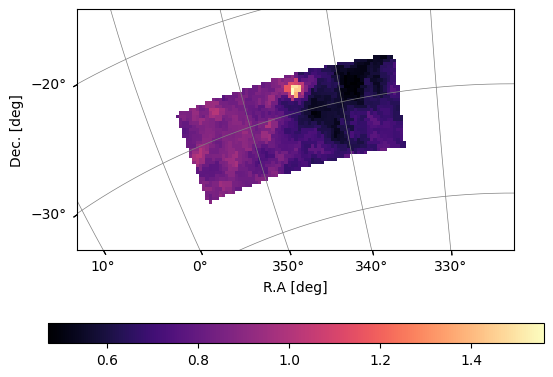

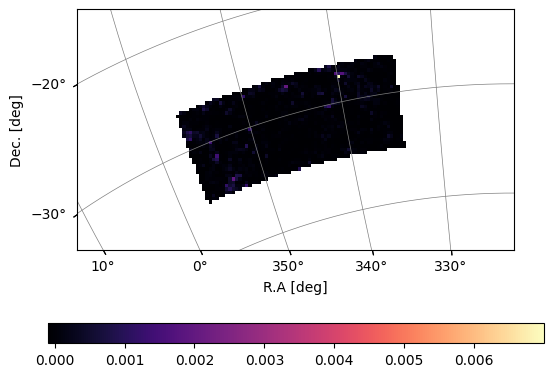

In [30]:
# plot one channel
plot_map(fg_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])
plot_map(hi_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])

The residual maps, on the other hand:

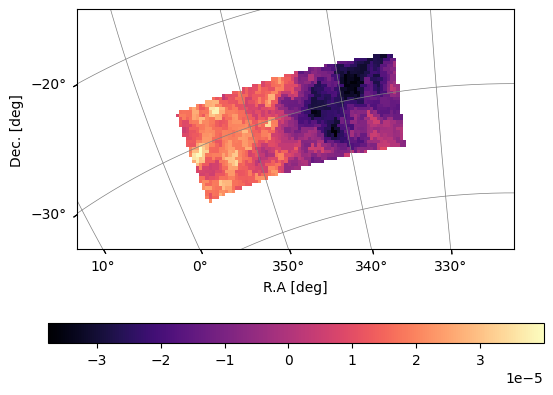

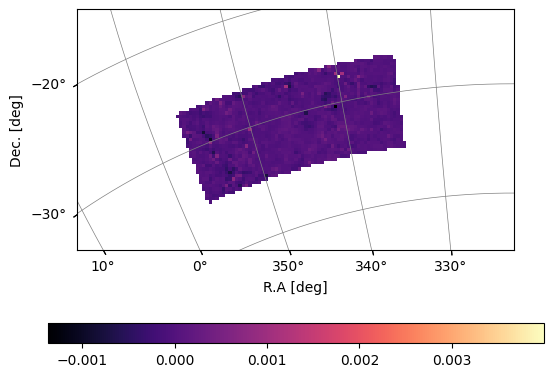

In [31]:
plot_map(res_fg_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])
plot_map(res_hi_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])




You can see, while the HI map is barely touched, the foreground is massively attenuated. On the other hand, the thermal noise is also not attenuated much:

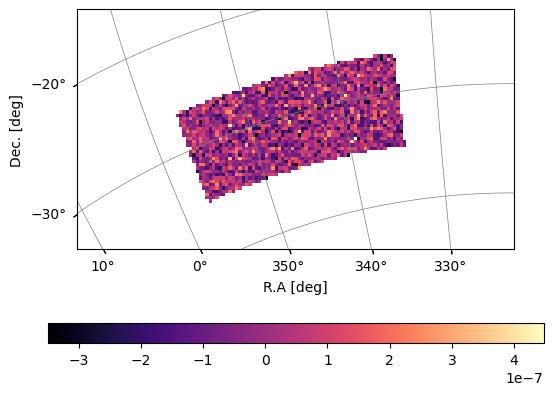

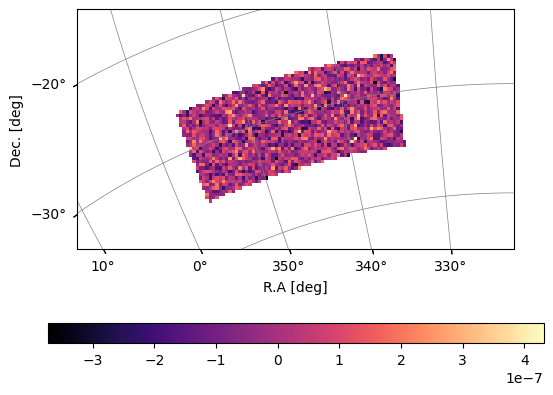

In [32]:
plot_map(noise_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])
plot_map(res_noise_map[:,:,0],mock.wproj, W=mock.w_HI[:,:,0])




Now let us look at the power spectrum:

In [33]:
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)

In [34]:
def cal_cy_power(data):
    mock.data = data
    mock.grid_data_to_field()
    power_cy,_ = mock.get_cy_power(mock.auto_power_3d_1)
    return power_cy



In [35]:
# get every component, residual and total
power_hi = cal_cy_power(hi_map)
power_fg = cal_cy_power(fg_map)
power_noise = cal_cy_power(noise_map)
power_tot = cal_cy_power(tot_map)
power_hi_res = cal_cy_power(res_hi_map)
power_fg_res = cal_cy_power(res_fg_map)
power_noise_res = cal_cy_power(res_noise_map)
power_tot_res = cal_cy_power(res_map)

Let us remind ourselves: In reality, we only have the total power spectrum (not useful, as it is dominated by foreground), and the residual power spectrum (which should be dominated by noise, but noise power spectrum can be calculated theoretically, so let us use power_tot_res - power_noise_res). We want to confirm that the residual is close to the original HI to show PCA is successful:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week7/tot_cylindrical_power_spectrum.pdf


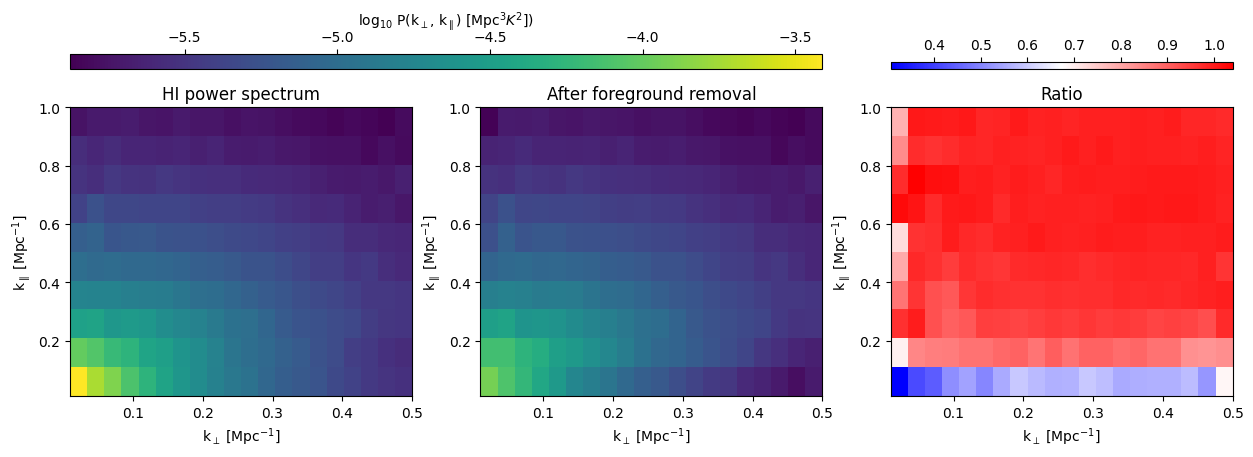

In [44]:
power_res = power_tot_res - power_noise_res
vmin = np.log10([np.abs(power_hi.min()),np.abs(power_res.min())]).min()
vmax = np.log10([np.abs(power_hi.max()),np.abs(power_res.max())]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('HI power spectrum')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('After foreground removal')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_res.T/power_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 7, filename = "tot_cylindrical_power_spectrum.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week7/hi_cylindrical_power_spectrum.pdf


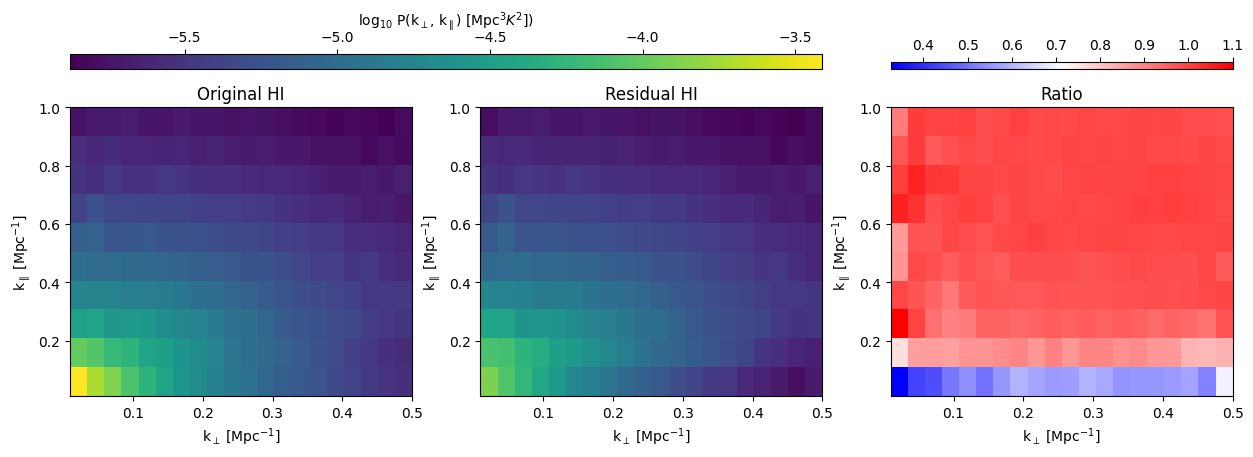

In [45]:
vmin = np.log10([np.abs(power_hi.min()),np.abs(power_hi_res.min())]).min()
vmax = np.log10([np.abs(power_hi.max()),np.abs(power_hi_res.max())]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('Original HI')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_hi_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('Residual HI')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_hi_res.T/power_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 7, filename = "hi_cylindrical_power_spectrum.pdf")
plt.show()

On the other hand, foreground is completely wiped out:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week7/fg_cylindrical_power_spectrum.pdf


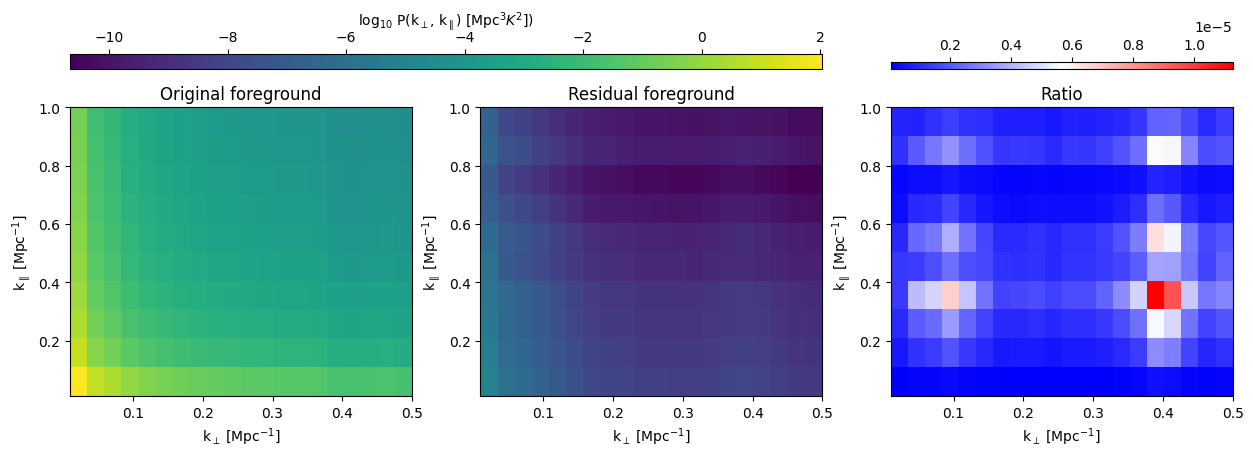

In [46]:
vmin = np.log10([np.abs(power_fg.min()),np.abs(power_fg_res.min())]).min()
vmax = np.log10([np.abs(power_fg.max()),np.abs(power_fg_res.max())]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_fg.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('Original foreground')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_fg_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('Residual foreground')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_fg_res.T/power_fg.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 7, filename = "fg_cylindrical_power_spectrum.pdf")
plt.show()

Noise is barely changed (and can be calculated to subtract out):

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week7/noise_cylindrical_power_spectrum.pdf


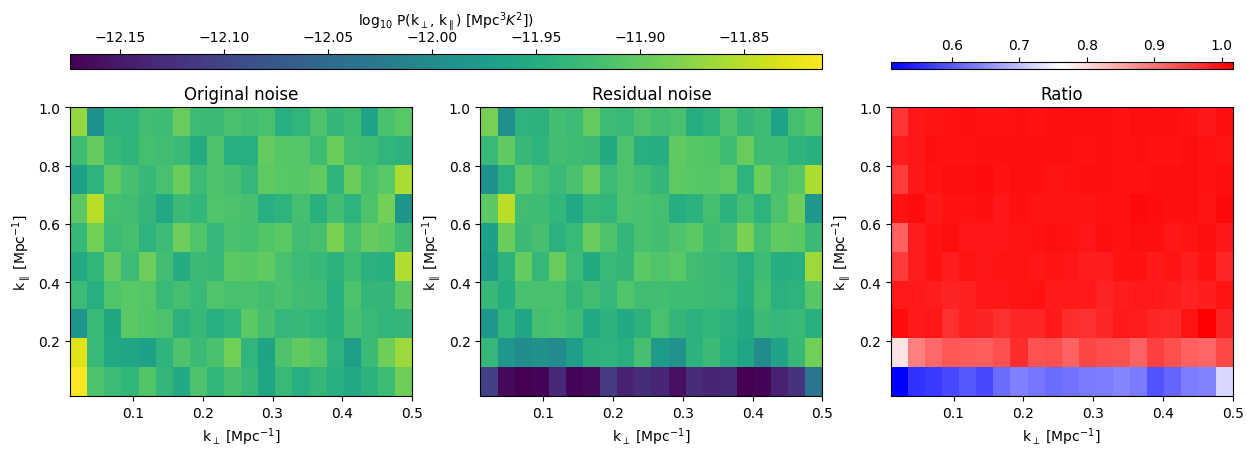

In [43]:
vmin = np.log10([np.abs(power_noise.min()),np.abs(power_noise_res.min())]).min()
vmax = np.log10([np.abs(power_noise.max()),np.abs(power_noise_res.max())]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_noise.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('Original noise')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_noise_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('Residual noise')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_noise_res.T/power_noise.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 7, filename = "noise_cylindrical_power_spectrum.pdf")
plt.show()